# Deutsch-Jozsa: is a hidden function constant or balanced?

A black box (the "oracle") computes a function $f$. It takes an $n$-bit string $x$ and returns one bit, $f(x)$. We are promised that $f$ is one of two kinds:

- **constant**: $f(x)$ is the same for every $x$.
- **balanced**: $f(x)=0$ for exactly half of the inputs and $1$ for the other half.

Which kind is it? Classically, you may need $2^{n-1}+1$ calls to the oracle in the worst case. Deutsch-Jozsa answers with a **single** call.

## How it works

1. Hadamards put the $n$ input qubits into an equal superposition of all $2^n$ strings, so one oracle call touches every input at once. (Measuring that state right away would reveal only one random $x$. The advantage comes from the interference in step 3.)
2. The ancilla qubit starts in $|-\rangle$. With the ancilla in $|-\rangle$, the oracle's "XOR $f(x)$ into the ancilla" becomes a phase of $(-1)^{f(x)}$ on each input $|x\rangle$ (this is *phase kickback*):
$$U_f\,|x\rangle|-\rangle = (-1)^{f(x)}\,|x\rangle|-\rangle$$
3. Hadamards again make the amplitudes interfere. The amplitude of $|0\cdots0\rangle$ is the average of $(-1)^{f(x)}$ over all $x$:
$$\frac{1}{2^n}\sum_x (-1)^{f(x)} = \begin{cases} \pm 1 & f \text{ constant}\\ 0 & f \text{ balanced}\end{cases}$$
4. Measure the inputs. All zeros means constant; anything else means balanced.

## The circuit ($n$ input qubits, 1 ancilla)

```
inputs  : |0>^n --H^n--[ oracle U_f ]--H^n--measure
ancilla : |1>   --H----[            ]
```

## The oracles

| Oracle | Function | Gates |
|---|---|---|
| `constant0` | $f(x)=0$ | none |
| `constant1` | $f(x)=1$ | `X` on the ancilla |
| `balanced` | $f(x)=(s\cdot x)\oplus b$ | `CX` from each input where $s$ has a 1, plus `X` if $b=1$ |

Here $s$ is a nonzero $n$-bit mask and $s\cdot x$ is the parity of the bits of $x$ selected by $s$. Any nonzero $s$ gives a balanced function.

Because this oracle is linear (a parity function), the Hadamards in step 3 turn it into exactly $|s\rangle$. On a balanced oracle the output register equals the mask $s$ exactly, not just "something nonzero". Parity functions are only a small subset of all balanced functions, but they preview Bernstein-Vazirani.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# _common.py (in the parent folder) runs circuits on Aer and/or IBM hardware.
# Run this notebook from its own folder (the default in Jupyter and VS Code).
# The next line looks for _common.py one folder up.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit
    n=3,                         # number of input qubits
    mask=None,                   # balanced oracle: nonzero bitmask, e.g. 0b101 (None = 0b011)
    flip=False,                  # balanced oracle: also XOR the output with 1
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)
ORACLE_KINDS = ("constant0", "constant1", "balanced")
DEFAULT_MASK = 0b011  # not a palindrome, so it checks the bit ordering
n = SETTINGS.n

## Step 1: The oracle

Qubits $0$ to $n-1$ are the inputs. Qubit $n$ is the ancilla, which receives $f(x)$ by XOR. A constant-0 oracle does nothing, a constant-1 oracle flips the ancilla, and a balanced oracle computes a parity with `CX` gates.

In [2]:
def build_oracle(n, kind, mask=None, flip=False):
    # Build the Deutsch-Jozsa oracle U_f on n + 1 qubits.
    if kind not in ORACLE_KINDS:
        raise ValueError(f"kind must be one of {ORACLE_KINDS}, got {kind!r}")

    oracle = QuantumCircuit(n + 1, name=f"U_f[{kind}]")
    if kind == "constant1":
        oracle.x(n)
    elif kind == "balanced":
        mask = DEFAULT_MASK & ((1 << n) - 1) if mask is None else mask
        if not 0 < mask < (1 << n):
            raise ValueError(f"mask must be a nonzero {n}-bit value, got {mask}")
        for i in range(n):
            if (mask >> i) & 1:
                oracle.cx(i, n)
        if flip:
            oracle.x(n)
    return oracle

Let's look at all three oracles.

constant0


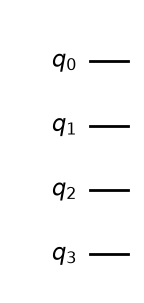

constant1


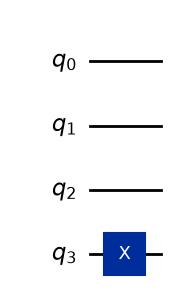

balanced


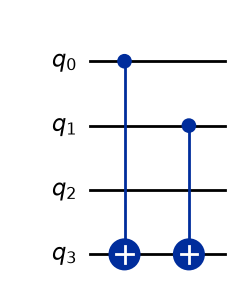

In [3]:
for kind in ORACLE_KINDS:
    print(kind)
    display(build_oracle(n, kind, mask=SETTINGS.mask, flip=SETTINGS.flip).draw("mpl"))

## Step 2: The full circuit

We wrap the oracle in the Deutsch-Jozsa circuit. The ancilla gets `X` then `H` to make $|-\rangle$, the inputs get `H` to make $|+\rangle^n$, and after the single oracle call the inputs get `H` again and are measured. The ancilla is never measured.

In [4]:
def build_deutsch_jozsa_circuit(n, oracle):
    inputs = QuantumRegister(n, name="x")
    ancilla = QuantumRegister(1, name="anc")
    bits = ClassicalRegister(n, name="meas")
    circuit = QuantumCircuit(inputs, ancilla, bits, name=f"deutsch_jozsa_{oracle.name}")

    # |+>^n on the inputs, |-> on the ancilla. Because the ancilla is in |->,
    # the oracle gives U_f |x>|-> = (-1)^f(x) |x>|->.
    circuit.x(ancilla)
    circuit.h(ancilla)
    circuit.h(inputs)
    circuit.barrier()

    # The single oracle call.
    circuit.compose(oracle, qubits=list(inputs) + list(ancilla), inplace=True)
    circuit.barrier()

    # Interfere, then measure only the input qubits.
    circuit.h(inputs)
    circuit.measure(inputs, bits)
    return circuit

Build one circuit per oracle and draw them. Compare the middle section (between the barriers) with the oracle diagrams above.

constant0


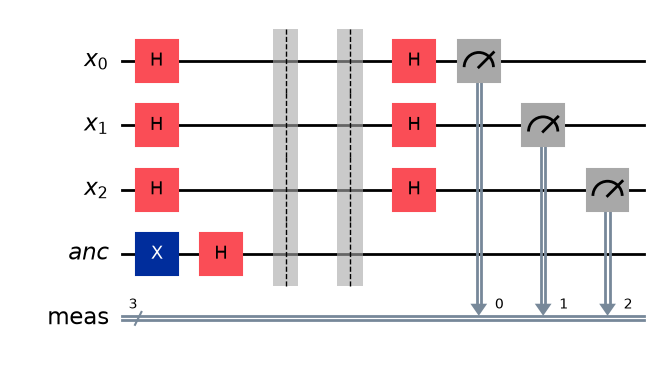

constant1


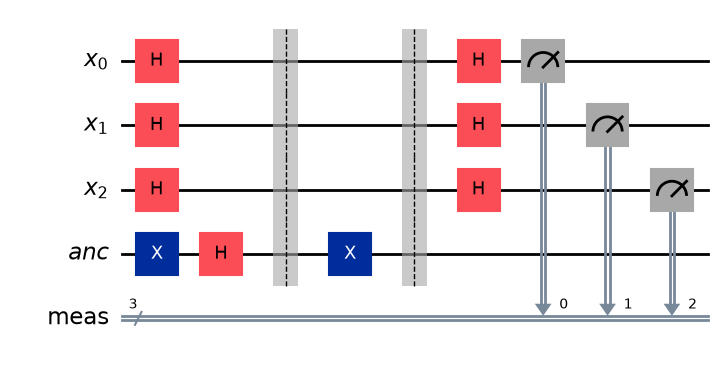

balanced


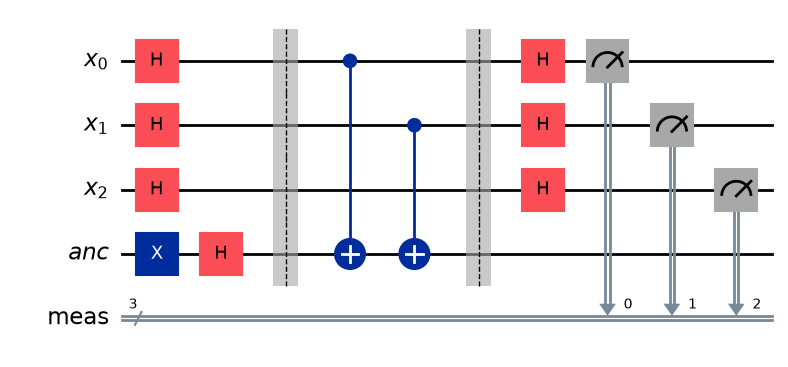

In [5]:
circuits = {
    kind: build_deutsch_jozsa_circuit(
        n, build_oracle(n, kind, mask=SETTINGS.mask, flip=SETTINGS.flip)
    )
    for kind in ORACLE_KINDS
}
for kind, circuit in circuits.items():
    print(kind)
    display(circuit.draw("mpl"))

## Step 3: Reading the answer

In theory a constant $f$ gives all zeros on every shot. Real hardware noise sends some shots elsewhere, so we use a majority vote: if all zeros is the majority outcome we say "constant", otherwise "balanced". Qiskit prints bitstrings with qubit 0 on the *right*.

In [6]:
def interpret(counts, n):
    zeros = counts.get("0" * n, 0)
    return "constant" if zeros > sum(counts.values()) / 2 else "balanced"


expected = {k: ("balanced" if k == "balanced" else "constant") for k in ORACLE_KINDS}


def report(prefix, name, counts):
    total = sum(counts.values())
    p0 = counts.get("0" * n, 0) / total
    verdict = interpret(counts, n)
    status = "correct" if verdict == expected[name] else "WRONG"
    print(
        f"[{prefix}] {name:<10} P(all zeros) = {p0:.3f} -> {verdict} "
        f"(expected {expected[name]}: {status})"
    )
    print(f"[{prefix}] counts: {counts}")

## Step 4: Run

`run_experiments` runs each circuit on the noiseless Aer simulator and, if `skip_hardware=False`, on IBM hardware too. On the simulator, the constant oracles should give $P(\text{all zeros})=1$ and the balanced oracle should give $P(\text{all zeros})=0$, exactly as the interference argument predicts. The balanced counts should show exactly the default mask `011` (qubit 0 is the rightmost character), which checks the bit ordering.

**What happens inside `run_experiments`.** For each backend, `_common.py` transpiles every circuit (`build_pubs`), wraps each one in a PUB, submits all the PUBs together as a single job, and matches each result back to its circuit (`counts_by_name`). One job means one wait in the hardware queue, however many circuits there are. These are the same steps as the six-step recipe in `01-Building-Blocks` (circuit, transpile, observable, PUB, execute, read). There is no observable here because we use a Sampler, which only returns bitstrings. Open `_common.py` to read the code.

In [7]:
args = SimpleNamespace(
    shots=SETTINGS.shots,
    backend=SETTINGS.backend,
    name=SETTINGS.name,
    skip_hardware=SETTINGS.skip_hardware,
    poll_interval=SETTINGS.poll_interval,
)
run_experiments(circuits, args, report);

Example circuit (deutsch_jozsa_U_f[constant0]):
        ┌───┐      ░  ░ ┌───┐┌─┐      
   x_0: ┤ H ├──────░──░─┤ H ├┤M├──────
        ├───┤      ░  ░ ├───┤└╥┘┌─┐   
   x_1: ┤ H ├──────░──░─┤ H ├─╫─┤M├───
        ├───┤      ░  ░ ├───┤ ║ └╥┘┌─┐
   x_2: ┤ H ├──────░──░─┤ H ├─╫──╫─┤M├
        ├───┤┌───┐ ░  ░ └───┘ ║  ║ └╥┘
   anc: ┤ X ├┤ H ├─░──░───────╫──╫──╫─
        └───┘└───┘ ░  ░       ║  ║  ║ 
meas: 3/══════════════════════╩══╩══╩═
                              0  1  2 

--- Aer simulator (noiseless), 4096 shots ---


[aer] constant0  P(all zeros) = 1.000 -> constant (expected constant: correct)
[aer] counts: {'000': 4096}
[aer] constant1  P(all zeros) = 1.000 -> constant (expected constant: correct)
[aer] counts: {'000': 4096}
[aer] balanced   P(all zeros) = 0.000 -> balanced (expected balanced: correct)
[aer] counts: {'011': 4096}


## Try it yourself

- Change `mask` to `0b101` and set `flip=True`. Does the balanced oracle still report "balanced"? Why?
- Change `n` to 5. How many oracle calls does the circuit still use?
- Classically, how many calls would you need in the worst case for $n=5$?